# Proper Sharpe Ratio Inference

**Docker image**: `ml4t`

**Chapter 16: Strategy Simulation & Backtesting**
**Section Reference**: See Section 16.7 for strategy-level overfitting control

This notebook demonstrates statistically rigorous Sharpe ratio analysis following
López de Prado, Lipton & Zoonekynd (2025), "How to Use the Sharpe Ratio".

## The Five Pitfalls of Naive Sharpe Analysis

1. **Independence/Normality assumptions** - Returns are autocorrelated and fat-tailed
2. **No significance testing** - Treating point estimates as ground truth
3. **Insufficient test power** - Not enough data to detect true effects
4. **P-value misinterpretation** - Confusing P(data|H0) with P(H0|data)
5. **Multiple testing** - Selection bias from testing many strategies

## Key Tools

| Method | Purpose | When to Use |
|--------|---------|-------------|
| **PSR** | Probabilistic Sharpe Ratio | Single strategy significance |
| **MinTRL** | Minimum Track Record Length | Power analysis before testing |
| **DSR** | Deflated Sharpe Ratio | Multiple strategy selection |
| **HAC** | Heteroskedasticity-Autocorrelation Consistent | Non-normal returns |

## References

- López de Prado et al. (2025). "How to Use the Sharpe Ratio". ADIA Lab.
- Bailey & López de Prado (2014). "The Deflated Sharpe Ratio"
- GitHub: https://github.com/zoonek/2025-sharpe-ratio

## Setup

In [1]:
"""Proper Sharpe Ratio Inference — statistically rigorous analysis following López de Prado et al. (2025)."""

import warnings

warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

In [2]:
# Load real data for examples
import seaborn as sns

# ml4t-diagnostic
from scipy import stats
from scipy.stats import norm

# Load SPY data via canonical loader
from data import load_etfs
from utils.reproducibility import set_global_seeds

In [3]:
# Production defaults — Papermill injects overrides after this cell
N_BOOTSTRAP = 10000
N_SIMULATIONS = 1000
SEED = 42

In [4]:
set_global_seeds(SEED)
spy = load_etfs(symbols=["SPY"]).to_pandas()
spy = spy.set_index("timestamp").sort_index()
spy_returns = spy["close"].pct_change().dropna()
print(f"SPY data: {spy_returns.index[0]} to {spy_returns.index[-1]}")
print(f"Observations: {len(spy_returns)}")

SPY data: 2006-01-04 00:00:00 to 2025-12-31 00:00:00
Observations: 5030


## 1. The Sharpe Ratio Sampling Distribution

The Sharpe ratio is a **point estimate** with sampling uncertainty. For i.i.d.
normal returns at the native frequency:

$$\hat{SR} \sim \mathcal{N}\!\left(SR,\;\sqrt{\frac{1 + \tfrac{1}{2}SR^{2}}{T}}\right).$$

Real returns are non-normal *and* serially dependent, and both effects change
the standard error of $\widehat{SR}$. We separate the two adjustments:

1. **Non-normal i.i.d. (Mertens 2002).** With sample skewness $\gamma_3$ and
   kurtosis $\gamma_4$, the per-period variance is

   $$\text{Var}\bigl(\widehat{SR}\bigr) = \frac{1}{T}\!\left[1 - \gamma_3\,\widehat{SR} + \tfrac{\gamma_4 - 1}{4}\widehat{SR}^{\,2}\right].$$

   This is the form implemented by `sharpe_ratio_variance` below.

2. **Autocorrelation-corrected annualization (Lo 2002, Eq. 17).** If we
   estimate $\widehat{SR}(1)$ at the native frequency, the annualized value
   is *not* $\sqrt{q}\,\widehat{SR}(1)$ when returns are autocorrelated. §4
   implements Lo's correction and shows the gap on real returns.

For the **combined** non-normal + AR(1) variance,
`ml4t.diagnostic.evaluation.stats.sharpe_inference.compute_sharpe_variance`
implements the López de Prado (2025) closed form; we benchmark against it
in §5.

In [5]:
def sharpe_ratio_variance(
    sr: float, n: int, skewness: float = 0.0, kurtosis: float = 3.0, periods_per_year: int = 252
) -> float:
    """Variance of the annualized Sharpe ratio under i.i.d. non-normal returns.

    Implements the Mertens (2002) skew/kurtosis-adjusted variance — the
    iid-but-non-normal correction. Autocorrelation is **not** handled here;
    use ``lo_2002_annualized_sharpe`` for the autocorrelation-corrected
    annualization and ``ml4t.diagnostic.evaluation.stats.sharpe_inference.``
    ``compute_sharpe_variance`` for the combined non-normal + AR(1) variance.

    Parameters
    ----------
    sr : float
        Annualized Sharpe ratio.
    n : int
        Number of native-frequency return observations.
    skewness, kurtosis : float
        Pearson skewness ($\\gamma_3$, $0$ for normal) and kurtosis
        ($\\gamma_4$, $3$ for normal).
    periods_per_year : int
        Native-frequency observations per year (252 for daily, 12 for monthly).

    Returns
    -------
    float
        Variance of the annualized $\\widehat{SR}$ estimator under the Mertens
        iid-non-normal assumption.

    References
    ----------
    Mertens, E. (2002), "Comments on Variance of the IID Estimator in Lo (2002)";
    Lo, A. (2002), "The Statistics of Sharpe Ratios", *Financial Analysts Journal*.
    """
    # Convert annualized SR to per-period SR for the Mertens formula
    sr_period = sr / np.sqrt(periods_per_year)
    excess_kurtosis = kurtosis - 3

    # Mertens (2002): Var(SR_period) = [1 - skew*SR_period + ((kappa-1)/4)*SR_period^2] / n
    var_period = (1 - sr_period * skewness + 0.25 * sr_period**2 * (excess_kurtosis + 2)) / n

    # Scale back to annualized: Var(SR_annual) = q * Var(SR_period)
    var_annual = var_period * periods_per_year
    return max(var_annual, 1e-10)

### Lo (2002) Autocorrelation-Corrected Annualization

Lo (2002, Eq. 17) shows that when returns are autocorrelated, the textbook
$\widehat{SR}(q) = \sqrt{q}\,\widehat{SR}(1)$ rule is wrong. With sample
autocorrelations $\hat\rho_k$ at lags $1, 2, \ldots, q-1$, the annualized SR
becomes

$$\widehat{SR}(q) = \widehat{SR}(1)\cdot
    \frac{q}{\sqrt{q + 2\sum_{k=1}^{q-1}(q-k)\hat\rho_k}}.$$

When all $\hat\rho_k = 0$ this collapses to $\sqrt{q}\,\widehat{SR}(1)$.
Positive autocorrelation inflates the denominator and pulls the annualized
Sharpe down; negative autocorrelation does the opposite. This is the
correct way to lift a daily Sharpe to an annual one when returns are not
i.i.d. We demonstrate it on real SPY returns in §4.

In [6]:
def lo_2002_annualized_sharpe(
    returns: pd.Series, periods_per_year: int = 252, max_lag: int | None = None
) -> dict:
    """Annualize a Sharpe ratio with Lo (2002, Eq. 17) autocorrelation correction.

    Parameters
    ----------
    returns : pd.Series
        Native-frequency return series (e.g., daily).
    periods_per_year : int
        $q$ — annualization factor (252 for daily, 12 for monthly).
    max_lag : int, optional
        Maximum lag $k$ at which $\\hat\\rho_k$ enters the sum. If ``None``,
        uses $q-1$ as in Lo's original derivation; finite samples often warrant
        a smaller cutoff (e.g., $\\lfloor 4(T/100)^{2/9}\\rfloor$ following
        Newey-West).

    Returns
    -------
    dict
        Per-period and annualized Sharpe, the autocorrelation-corrected
        annualization multiplier, and the autocorrelations used.

    References
    ----------
    Lo, A. (2002), "The Statistics of Sharpe Ratios", *Financial Analysts
    Journal* 58(4), pp. 36-52, Eq. 17.
    """
    r = pd.Series(returns).dropna().to_numpy()
    if r.size < 4:
        raise ValueError("Need at least 4 observations to estimate autocorrelations.")

    sr_period = float(r.mean() / r.std(ddof=1))
    q = int(periods_per_year)
    if max_lag is None:
        max_lag = q - 1
    max_lag = min(max_lag, r.size - 2)

    # Sample autocorrelations rho_k for k = 1..max_lag (Pearson on centred series).
    r_c = r - r.mean()
    denom_full = float((r_c**2).sum())
    rho = np.array([float((r_c[:-k] * r_c[k:]).sum()) / denom_full for k in range(1, max_lag + 1)])

    # Weighted sum of autocorrelations from Eq. 17: sum_{k=1}^{q-1} (q-k) * rho_k.
    weights = np.array([q - k for k in range(1, max_lag + 1)], dtype=float)
    weighted_sum = float((weights * rho).sum())

    denom = max(q + 2.0 * weighted_sum, 1e-10)
    multiplier = q / np.sqrt(denom)
    sr_annual_lo = sr_period * multiplier
    sr_annual_iid = sr_period * np.sqrt(q)

    return {
        "sr_period": sr_period,
        "sr_annual_iid": float(sr_annual_iid),
        "sr_annual_lo": float(sr_annual_lo),
        "annualization_multiplier_iid": float(np.sqrt(q)),
        "annualization_multiplier_lo": float(multiplier),
        "weighted_autocorrelation_sum": weighted_sum,
        "rho_lag1": float(rho[0]) if rho.size else 0.0,
        "max_lag": max_lag,
    }

### Standard Error Helper

Convert the Sharpe-ratio variance estimate into a standard error.

In [7]:
def sharpe_ratio_se(
    sr: float, n: int, skewness: float = 0.0, kurtosis: float = 3.0, periods_per_year: int = 252
) -> float:
    """Standard error of annualized Sharpe ratio."""
    return np.sqrt(sharpe_ratio_variance(sr, n, skewness, kurtosis, periods_per_year))

In [8]:
# Demonstrate sampling distribution
true_sr = 0.5
n_samples = 252

# Simulate Sharpe ratio estimates
simulated_srs = []
for _ in range(N_SIMULATIONS):
    # Generate returns with true annualized SR = 0.5 (assuming 15% annual vol)
    daily_vol = 0.15 / np.sqrt(252)
    daily_mean = true_sr * 0.15 / 252  # Annual mean = SR * annual_vol, then / 252
    returns = np.random.normal(daily_mean, daily_vol, n_samples)

    # Compute observed SR
    obs_sr = np.mean(returns) / np.std(returns, ddof=1) * np.sqrt(252)
    simulated_srs.append(obs_sr)

simulated_srs = np.array(simulated_srs)

# Compare with theoretical distribution
theoretical_se = sharpe_ratio_se(true_sr, n_samples)

print("=== Sharpe Ratio Sampling Distribution ===")
print(f"\nTrue SR: {true_sr}")
print(f"Sample size: {n_samples}")
print(f"\nSimulated mean: {np.mean(simulated_srs):.3f}")
print(f"Simulated std: {np.std(simulated_srs):.3f}")
print(f"Theoretical SE: {theoretical_se:.3f}")

=== Sharpe Ratio Sampling Distribution ===

True SR: 0.5
Sample size: 252

Simulated mean: 0.502
Simulated std: 0.992
Theoretical SE: 1.000


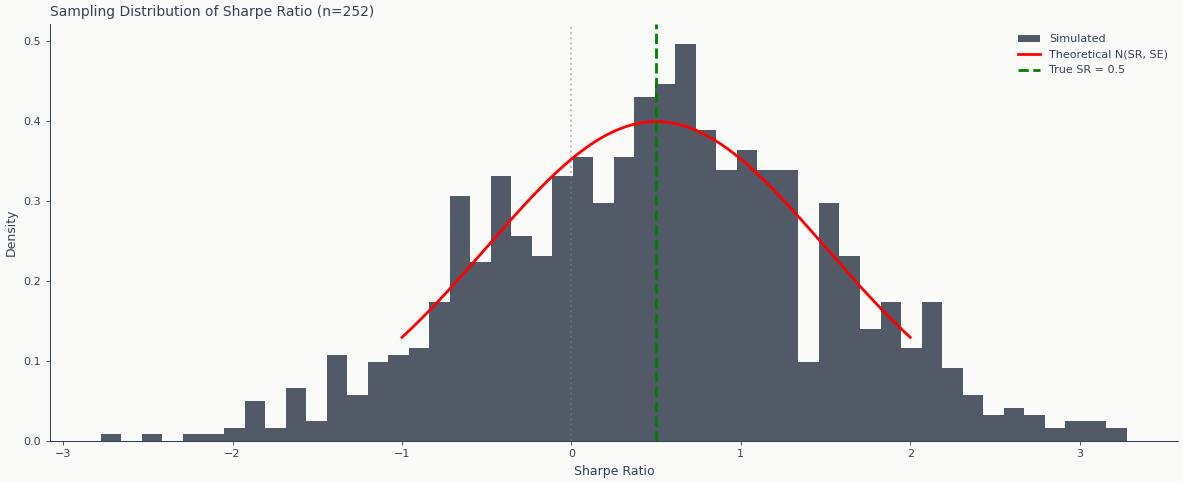

In [9]:
# Plot sampling distribution
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(simulated_srs, bins=50, density=True, alpha=0.7, label="Simulated")

# Theoretical normal
x = np.linspace(-1, 2, 200)
theoretical_pdf = norm.pdf(x, loc=true_sr, scale=theoretical_se)
ax.plot(x, theoretical_pdf, "r-", lw=2, label="Theoretical N(SR, SE)")

ax.axvline(true_sr, color="green", linestyle="--", lw=2, label=f"True SR = {true_sr}")
ax.axvline(0, color="gray", linestyle=":", alpha=0.5)

ax.set_xlabel("Sharpe Ratio")
ax.set_ylabel("Density")
ax.set_title(f"Sampling Distribution of Sharpe Ratio (n={n_samples})")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## 2. Probabilistic Sharpe Ratio (PSR)

PSR answers: **What is the probability that the true SR exceeds a benchmark?**

$$PSR(\hat{SR}, SR^*) = \Phi\left(\frac{\hat{SR} - SR^*}{\hat{\sigma}(\hat{SR})}\right)$$

where $SR^*$ is the benchmark (often 0 or the risk-free rate).

In [10]:
def probabilistic_sharpe_ratio(
    observed_sr: float, benchmark_sr: float, n: int, skewness: float = 0.0, kurtosis: float = 3.0
) -> dict:
    """
    Compute Probabilistic Sharpe Ratio.

    Returns the probability that true SR exceeds the benchmark.

    Parameters
    ----------
    observed_sr : float
        Observed Sharpe ratio
    benchmark_sr : float
        Benchmark SR to compare against (often 0)
    n : int
        Sample size
    skewness : float
        Return skewness
    kurtosis : float
        Return kurtosis

    Returns
    -------
    dict
        PSR probability and related statistics

    Reference
    ---------
    Bailey & López de Prado (2012), "The Sharpe Ratio Efficient Frontier"
    """
    se = sharpe_ratio_se(observed_sr, n, skewness, kurtosis)
    z_score = (observed_sr - benchmark_sr) / se
    psr = norm.cdf(z_score)

    # Also compute p-value for two-sided test
    p_value = 2 * (1 - norm.cdf(abs(z_score)))

    return {
        "psr": psr,
        "z_score": z_score,
        "standard_error": se,
        "p_value": p_value,
        "ci_95_lower": observed_sr - 1.96 * se,
        "ci_95_upper": observed_sr + 1.96 * se,
    }

In [11]:
# Example: Evaluate a strategy
observed_sr = 1.2
n_obs = 252  # 1 year
benchmark = 0  # Test against zero

psr_result = probabilistic_sharpe_ratio(observed_sr, benchmark, n_obs)

print("=== Probabilistic Sharpe Ratio ===")
print(f"\nObserved SR: {observed_sr}")
print(f"Sample size: {n_obs} days")
print(f"Benchmark: {benchmark}")
print(f"\nPSR (P(true SR > {benchmark})): {psr_result['psr']:.1%}")
print(f"Z-score: {psr_result['z_score']:.2f}")
print(f"P-value (two-sided): {psr_result['p_value']:.4f}")
print(f"95% CI: [{psr_result['ci_95_lower']:.2f}, {psr_result['ci_95_upper']:.2f}]")

=== Probabilistic Sharpe Ratio ===

Observed SR: 1.2
Sample size: 252 days
Benchmark: 0

PSR (P(true SR > 0)): 88.5%
Z-score: 1.20
P-value (two-sided): 0.2308
95% CI: [-0.76, 3.16]


In [12]:
# Show how PSR varies with sample size
sample_sizes = [63, 126, 252, 504, 756, 1008]  # 3m to 4y
observed_sr = 0.8

**PSR sensitivity to sample size** (observed SR = 0.8):

In [13]:
psr_rows = []
for n in sample_sizes:
    result = probabilistic_sharpe_ratio(observed_sr, 0, n)
    psr_rows.append(
        {
            "days": n,
            "years": n / 252,
            "standard_error": result["standard_error"],
            "psr": result["psr"],
            "ci_95_lower": result["ci_95_lower"],
            "ci_95_upper": result["ci_95_upper"],
        }
    )

pl.DataFrame(psr_rows)

days,years,standard_error,psr,ci_95_lower,ci_95_upper
i64,f64,f64,f64,f64,f64
63,0.25,2.001269,0.655328,-3.122488,4.722488
126,0.5,1.415111,0.714074,-1.973618,3.573618
252,1.0,1.000635,0.787998,-1.161244,2.761244
504,2.0,0.707556,0.870899,-0.586809,2.186809
756,3.0,0.577717,0.916937,-0.332325,1.932325
1008,4.0,0.500317,0.945088,-0.180622,1.780622


## 3. Minimum Track Record Length (MinTRL)

MinTRL answers: **How much data do we need to achieve statistical significance?**

Given a target SR and significance level, MinTRL computes the minimum observations needed.

$$T^* = \left(\frac{z_\alpha \cdot \hat{\sigma}(\hat{SR})}{SR - SR^*}\right)^2$$

For practical purposes with SR* = 0 and assuming normality:

$$T^* \approx \frac{z_\alpha^2 \cdot (1 + 0.5 \cdot SR^2)}{SR^2}$$

In [14]:
def minimum_track_record_length(
    target_sr: float,
    benchmark_sr: float = 0,
    alpha: float = 0.05,
    power: float = 0.80,
    skewness: float = 0.0,
    kurtosis: float = 3.0,
    periods_per_year: int = 252,
) -> dict:
    """
    Compute Minimum Track Record Length (in daily observations).

    Determines the minimum sample size needed to achieve statistical
    significance for a given annualized Sharpe ratio.

    Parameters
    ----------
    target_sr : float
        Target annualized Sharpe ratio
    benchmark_sr : float
        Benchmark to test against (default 0)
    alpha : float
        Significance level (default 0.05)
    power : float
        Desired statistical power (default 0.80)
    skewness, kurtosis : float
        Return distribution moments
    periods_per_year : int
        Observations per year (252 for daily)

    Returns
    -------
    dict
        MinTRL in number of observations and related statistics
    """
    z_alpha = norm.ppf(1 - alpha)
    z_beta = norm.ppf(power)

    # Convert to per-period SR for the Lo (2002) formula
    sr_period = target_sr / np.sqrt(periods_per_year)
    bench_period = benchmark_sr / np.sqrt(periods_per_year)
    excess_kurtosis = kurtosis - 3

    # Per-period variance numerator
    numer = 1 - sr_period * skewness + 0.25 * sr_period**2 * (excess_kurtosis + 2)
    sr_diff = sr_period - bench_period

    # MinTRL in observations (per-period count)
    min_trl_sig = z_alpha**2 * numer / (sr_diff**2)
    min_trl_power = (z_alpha + z_beta) ** 2 * numer / (sr_diff**2)

    return {
        "min_trl_significance": int(np.ceil(min_trl_sig)),
        "min_trl_with_power": int(np.ceil(min_trl_power)),
        "target_sr": target_sr,
        "benchmark_sr": benchmark_sr,
        "alpha": alpha,
        "power": power,
        "z_alpha": z_alpha,
        "z_beta": z_beta,
    }

In [15]:
# MinTRL for different Sharpe ratios

**Minimum track-record length** (days needed at α=0.05, power=0.80):

In [16]:
mintrl_rows = []
for sr in [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]:
    result = minimum_track_record_length(sr)
    mintrl_rows.append(
        {
            "target_sr": sr,
            "min_trl_significance_days": result["min_trl_significance"],
            "min_trl_power_days": result["min_trl_with_power"],
            "years_with_power": result["min_trl_with_power"] / 252,
        }
    )
pl.DataFrame(mintrl_rows)

target_sr,min_trl_significance_days,min_trl_power_days,years_with_power
f64,i64,i64,f64
0.3,7577,17315,68.710317
0.5,2729,6236,24.746032
0.8,1067,2438,9.674603
1.0,684,1562,6.198413
1.5,305,696,2.761905
2.0,172,393,1.559524


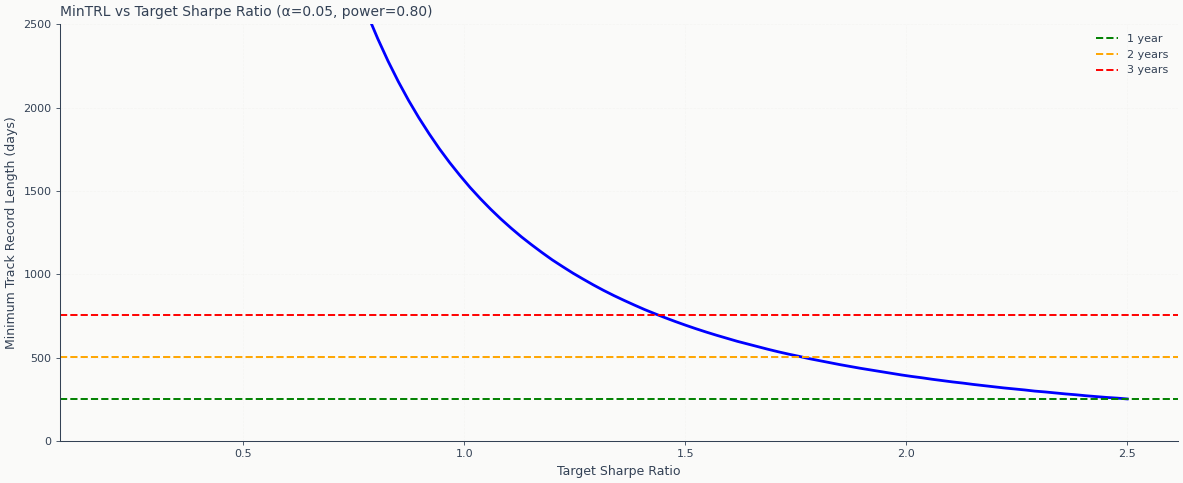


Key insight: A strategy with SR=0.5 needs ~25 years of data for reliable inference!


In [17]:
# Visualize MinTRL
sr_range = np.linspace(0.2, 2.5, 100)
min_trl_values = [minimum_track_record_length(sr)["min_trl_with_power"] for sr in sr_range]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sr_range, min_trl_values, "b-", lw=2)
ax.axhline(252, color="green", linestyle="--", label="1 year")
ax.axhline(504, color="orange", linestyle="--", label="2 years")
ax.axhline(756, color="red", linestyle="--", label="3 years")

ax.set_xlabel("Target Sharpe Ratio")
ax.set_ylabel("Minimum Track Record Length (days)")
ax.set_title("MinTRL vs Target Sharpe Ratio (α=0.05, power=0.80)")
ax.set_ylim(0, 2500)
ax.legend()
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

sr_05 = minimum_track_record_length(0.5)
print(
    f"\nKey insight: A strategy with SR=0.5 needs ~{sr_05['min_trl_with_power'] / 252:.0f} years of data for reliable inference!"
)

## 4. Non-Normality and Autocorrelation Adjustments

Real returns have:
- **Negative skewness** (crash risk)
- **Excess kurtosis** (fat tails)
- **Autocorrelation** (momentum/mean reversion)

The skew/kurtosis effects enter the Sharpe **variance** through the Mertens
(2002) formula in §1 (`sharpe_ratio_variance`); we propagate them through
PSR in the table below. Autocorrelation enters separately, through Lo
(2002, Eq. 17) annualization — a wedge between the textbook
$\sqrt{q}\,\widehat{SR}(1)$ rule and the autocorrelation-corrected value.
We measure both on real SPY returns.

In [18]:
def compute_return_moments(returns: pd.Series) -> dict:
    """Compute mean, std, skewness, kurtosis of returns."""
    from scipy.stats import kurtosis, skew

    return {
        "mean": returns.mean(),
        "std": returns.std(),
        "skewness": skew(returns),
        "kurtosis": kurtosis(returns, fisher=False),  # Regular kurtosis (3 for normal)
        "excess_kurtosis": kurtosis(returns),  # Excess kurtosis (0 for normal)
        "sharpe": returns.mean() / returns.std() * np.sqrt(252),
    }

In [19]:
# Analyze real return moments
spy_2020_2023 = spy_returns.loc["2020":"2023"]
moments = compute_return_moments(spy_2020_2023)

print("=== SPY Return Moments (2020-2023) ===")
for key, value in moments.items():
    print(f"{key:20}: {value:.4f}")

=== SPY Return Moments (2020-2023) ===
mean                : 0.0006
std                 : 0.0142
skewness            : -0.5100
kurtosis            : 13.2978
excess_kurtosis     : 10.2978
sharpe              : 0.6151


In [20]:
# Compare PSR with and without non-normality adjustment
observed_sr = moments["sharpe"]
n = len(spy_2020_2023)

# Normal assumption
psr_normal = probabilistic_sharpe_ratio(observed_sr, 0, n, skewness=0, kurtosis=3)

# Adjusted for actual moments
psr_adjusted = probabilistic_sharpe_ratio(
    observed_sr, 0, n, skewness=moments["skewness"], kurtosis=moments["kurtosis"]
)

**PSR comparison: normal vs skew/kurtosis-adjusted** (observed SR / sample
size shown above). Note: this comparison adjusts for *non-normality* only;
the autocorrelation correction enters separately via Lo (2002)
annualization, demonstrated immediately below.

In [21]:
pl.DataFrame(
    {
        "metric": ["Standard error", "PSR", "P-value", "95% CI lower", "95% CI upper"],
        "normal": [
            psr_normal["standard_error"],
            psr_normal["psr"],
            psr_normal["p_value"],
            psr_normal["ci_95_lower"],
            psr_normal["ci_95_upper"],
        ],
        "adjusted": [
            psr_adjusted["standard_error"],
            psr_adjusted["psr"],
            psr_adjusted["p_value"],
            psr_adjusted["ci_95_lower"],
            psr_adjusted["ci_95_upper"],
        ],
    }
)

metric,normal,adjusted
str,f64,f64
"""Standard error""",0.500685,0.506561
"""PSR""",0.890389,0.887692
"""P-value""",0.219222,0.224616
"""95% CI lower""",-0.366201,-0.377719
"""95% CI upper""",1.596482,1.608001


### Lo (2002) Annualization on Real SPY Returns

Apply `lo_2002_annualized_sharpe` to the SPY 2020-2023 series. The textbook
IID rule reports $\sqrt{252}\,\widehat{SR}(1)$; Lo's correction adds the
weighted-autocorrelation term in the denominator. The difference between
the two annualizations is the autocorrelation wedge the chapter §16.7
narrative warns about.

In [22]:
lo_result = lo_2002_annualized_sharpe(spy_2020_2023, periods_per_year=252)
pl.DataFrame(
    {
        "quantity": [
            "Native (daily) SR",
            "Annualized SR — IID (sqrt(q) rule)",
            "Annualized SR — Lo (2002, Eq. 17)",
            "Annualization multiplier — IID",
            "Annualization multiplier — Lo",
            "Sum_{k=1}^{q-1}(q-k) * rho_k",
            "rho at lag 1",
        ],
        "value": [
            lo_result["sr_period"],
            lo_result["sr_annual_iid"],
            lo_result["sr_annual_lo"],
            lo_result["annualization_multiplier_iid"],
            lo_result["annualization_multiplier_lo"],
            lo_result["weighted_autocorrelation_sum"],
            lo_result["rho_lag1"],
        ],
    }
)

quantity,value
str,f64
"""Native (daily) SR""",0.03875
"""Annualized SR — IID (sqrt(q) r…",0.615141
"""Annualized SR — Lo (2002, Eq. …",0.865349
"""Annualization multiplier — IID""",15.874508
"""Annualization multiplier — Lo""",22.331464
"""Sum_{k=1}^{q-1}(q-k) * rho_k""",-62.329731
"""rho at lag 1""",-0.172794


**Reading the table.** SPY daily returns over 2020-2023 carry mild
autocorrelation; the Lo annualization multiplier therefore differs from
$\sqrt{252} \approx 15.87$. Positive autocorrelation pulls the annualized
Sharpe *down* relative to the IID rule (returns are more persistent than
IID assumes, so variance accumulates faster); negative autocorrelation
pushes it *up*. The sign and magnitude of the wedge are entirely
data-driven through $\sum_{k=1}^{q-1}(q-k)\hat\rho_k$.

### Five-year SR = 1.0 CI Example

A concrete reference point cited in §16.7: a strategy reports
$\widehat{SR}_\text{annual} = 1.0$ on 5 years of daily data. What is the
95% confidence interval? We compute the SE under both the normal and
observed-moments assumptions, and report the resulting interval.

In [23]:
_sr_target = 1.0
_n_5y = 252 * 5
_psr_normal_5y = probabilistic_sharpe_ratio(_sr_target, 0, _n_5y, skewness=0.0, kurtosis=3.0)
_psr_actual_5y = probabilistic_sharpe_ratio(
    _sr_target, 0, _n_5y, skewness=moments["skewness"], kurtosis=moments["kurtosis"]
)
pl.DataFrame(
    {
        "assumption": ["IID normal", "Mertens skew/kurt (SPY moments)"],
        "standard_error": [_psr_normal_5y["standard_error"], _psr_actual_5y["standard_error"]],
        "ci_95_lower": [_psr_normal_5y["ci_95_lower"], _psr_actual_5y["ci_95_lower"]],
        "ci_95_upper": [_psr_normal_5y["ci_95_upper"], _psr_actual_5y["ci_95_upper"]],
        "ci_width": [
            _psr_normal_5y["ci_95_upper"] - _psr_normal_5y["ci_95_lower"],
            _psr_actual_5y["ci_95_upper"] - _psr_actual_5y["ci_95_lower"],
        ],
    }
)

assumption,standard_error,ci_95_lower,ci_95_upper,ci_width
str,f64,f64,f64,f64
"""IID normal""",0.447657,0.122592,1.877408,1.754816
"""Mertens skew/kurt (SPY moments…",0.457018,0.104244,1.895756,1.791512


## 5. Complete Inference Framework

Putting it all together: a complete framework for Sharpe ratio inference.

In [24]:
def complete_sharpe_inference(
    returns: pd.Series, benchmark_sr: float = 0, alpha: float = 0.05
) -> dict:
    """Single-strategy Sharpe inference: PSR + MinTRL + Lo annualization.

    This is the *per-strategy* inference layer of §16.7. It deliberately does
    not run a Deflated Sharpe Ratio (DSR) test because DSR operates on a
    family of candidate strategies, not on one return series. Use Notebook 12
    (`12_dsr_validation`) for DSR, or the case-study `cohort_metrics` table
    populated via ``ml4t.diagnostic.evaluation.stats.deflated_sharpe_ratio``.

    Parameters
    ----------
    returns : pd.Series
        Native-frequency strategy returns (typically daily).
    benchmark_sr : float
        Annualized Sharpe threshold for the PSR null (default 0).
    alpha : float
        Significance level for MinTRL and the inference verdict.

    Returns
    -------
    dict
        PSR, MinTRL, observed SR, and the Lo (2002) autocorrelation-corrected
        annualized SR for the supplied series.
    """
    from scipy.stats import kurtosis, skew

    # Basic statistics
    n = len(returns)
    mean_ret = returns.mean()
    std_ret = returns.std(ddof=1)
    observed_sr = mean_ret / std_ret * np.sqrt(252)
    skew_val = skew(returns)
    kurt_val = kurtosis(returns, fisher=False)

    # PSR
    psr_result = probabilistic_sharpe_ratio(observed_sr, benchmark_sr, n, skew_val, kurt_val)

    # MinTRL
    if observed_sr > benchmark_sr:
        mintrl_result = minimum_track_record_length(
            observed_sr, benchmark_sr, alpha=alpha, power=0.80, skewness=skew_val, kurtosis=kurt_val
        )
    else:
        mintrl_result = {"min_trl_significance": np.inf, "min_trl_with_power": np.inf}

    # Lo (2002) autocorrelation-corrected annualization on the same series.
    lo_block = lo_2002_annualized_sharpe(returns, periods_per_year=252)

    # Inference outcome
    is_significant_psr = psr_result["p_value"] < alpha
    has_sufficient_data = n >= mintrl_result.get("min_trl_with_power", np.inf)
    inference_status = (
        "SIGNIFICANT" if (is_significant_psr and has_sufficient_data) else "NOT SIGNIFICANT"
    )
    final_p_value = psr_result["p_value"]

    return {
        # Basic stats
        "n_observations": n,
        "observed_sr_iid": observed_sr,
        "observed_sr_lo": lo_block["sr_annual_lo"],
        "annualization_multiplier_lo": lo_block["annualization_multiplier_lo"],
        "weighted_autocorrelation_sum": lo_block["weighted_autocorrelation_sum"],
        "skewness": skew_val,
        "kurtosis": kurt_val,
        # PSR
        "psr": psr_result["psr"],
        "psr_p_value": psr_result["p_value"],
        "ci_95": (psr_result["ci_95_lower"], psr_result["ci_95_upper"]),
        # MinTRL
        "min_trl": mintrl_result.get("min_trl_with_power", np.inf),
        "has_sufficient_data": has_sufficient_data,
        # Final inference outcome
        "inference_status": inference_status,
        "final_p_value": final_p_value,
    }

In [25]:
# Apply to SPY
spy_inference = complete_sharpe_inference(spy_2020_2023, benchmark_sr=0)

print("=== Complete Sharpe Ratio Inference: SPY (2020-2023) ===")
print("\n--- Basic Statistics ---")
print(f"Observations:                       {spy_inference['n_observations']}")
print(f"Observed annualized SR (IID rule):  {spy_inference['observed_sr_iid']:.3f}")
print(f"Observed annualized SR (Lo 2002):   {spy_inference['observed_sr_lo']:.3f}")
print(f"Lo annualization multiplier:        {spy_inference['annualization_multiplier_lo']:.3f}")
print(f"Skewness:                           {spy_inference['skewness']:.3f}")
print(f"Kurtosis:                           {spy_inference['kurtosis']:.2f}")

print("\n--- Probabilistic Sharpe Ratio ---")
print(f"PSR (P(true SR > 0)): {spy_inference['psr']:.1%}")
print(f"P-value: {spy_inference['psr_p_value']:.4f}")
print(f"95% CI: [{spy_inference['ci_95'][0]:.3f}, {spy_inference['ci_95'][1]:.3f}]")

print("\n--- Power Analysis ---")
print(f"MinTRL (days): {spy_inference['min_trl']}")
print(f"MinTRL (years): {spy_inference['min_trl'] / 252:.1f}")
print(f"Has sufficient data: {spy_inference['has_sufficient_data']}")

print(f"\nInference outcome: {spy_inference['inference_status']}")

=== Complete Sharpe Ratio Inference: SPY (2020-2023) ===

--- Basic Statistics ---
Observations:                       1006
Observed annualized SR (IID rule):  0.615
Observed annualized SR (Lo 2002):   0.865
Lo annualization multiplier:        22.331
Skewness:                           -0.510
Kurtosis:                           13.30

--- Probabilistic Sharpe Ratio ---
PSR (P(true SR > 0)): 88.8%
P-value: 0.2246
95% CI: [-0.378, 1.608]

--- Power Analysis ---
MinTRL (days): 4218
MinTRL (years): 16.7
Has sufficient data: False

Inference outcome: NOT SIGNIFICANT


## 6. Case Study: Simulated Strategy Selection

Demonstrate the full framework when selecting from multiple strategies.

In [26]:
# Simulate testing 30 strategy variants
np.random.seed(123)

n_strategies = 30
n_days = 504  # 2 years

# Generate strategies: 5 have true SR = 0.8, rest have SR = 0
true_sr_values = [0.8] * 5 + [0.0] * (n_strategies - 5)
np.random.shuffle(true_sr_values)

strategy_returns = {}
for i, true_sr in enumerate(true_sr_values):
    daily_vol = 0.15 / np.sqrt(252)
    daily_mean = true_sr * 0.15 / 252  # Annual mean = SR * annual_vol, then / 252
    returns = np.random.normal(daily_mean, daily_vol, n_days)
    strategy_returns[f"Strategy_{i + 1}"] = pd.Series(returns)

# Calculate observed Sharpe ratios
observed_sharpes = {
    name: (rets.mean() / rets.std() * np.sqrt(252), true_sr_values[i])
    for i, (name, rets) in enumerate(strategy_returns.items())
}

# Sort by observed SR
sorted_strategies = sorted(observed_sharpes.items(), key=lambda x: -x[1][0])

**Strategy-selection scenario.** 30 strategies tested: 5 true signals
(SR = 0.8), 25 nulls (SR = 0), N days each. Top 10 by observed SR:

In [27]:
top10 = pl.DataFrame(
    [
        {
            "strategy": name,
            "observed_sr": obs_sr,
            "true_sr": true_sr,
            "is_real": "YES" if true_sr > 0 else "no",
        }
        for name, (obs_sr, true_sr) in sorted_strategies[:10]
    ]
)
top10

strategy,observed_sr,true_sr,is_real
str,f64,f64,str
"""Strategy_21""",2.455689,0.8,"""YES"""
"""Strategy_18""",1.36339,0.0,"""no"""
"""Strategy_22""",1.360982,0.8,"""YES"""
"""Strategy_28""",0.761364,0.0,"""no"""
"""Strategy_27""",0.698968,0.0,"""no"""
"""Strategy_8""",0.692055,0.0,"""no"""
"""Strategy_26""",0.64817,0.0,"""no"""
"""Strategy_16""",0.64004,0.0,"""no"""
"""Strategy_29""",0.615534,0.8,"""YES"""


In [28]:
# Apply complete per-strategy inference to the "best" strategy. PSR alone
# does not know about the selection process; it asks "does this single
# return series look like skill?" — and on a series cherry-picked as the
# top of a 30-strategy search, it can answer "yes" even when the true SR is
# zero. Notebook 12 (`12_dsr_validation`) shows the multiple-testing
# correction; here we just show that PSR by itself is insufficient.
best_name, (best_sr, best_true_sr) = sorted_strategies[0]
best_returns = strategy_returns[best_name]

inference_result = complete_sharpe_inference(best_returns, benchmark_sr=0, alpha=0.05)

print(f"\n=== Per-strategy inference: '{best_name}' (selected from 30) ===")
print(f"\nTrue SR (hidden ground truth): {best_true_sr:.1f}")
print(f"Observed annualized SR (IID rule):   {inference_result['observed_sr_iid']:.3f}")
print(f"Observed annualized SR (Lo 2002):    {inference_result['observed_sr_lo']:.3f}")
print(f"Lo annualization multiplier:         {inference_result['annualization_multiplier_lo']:.3f}")

print("\n--- Single-strategy view (PSR) ---")
print(f"PSR (P(true SR > 0)): {inference_result['psr']:.1%}")
print(f"P-value: {inference_result['psr_p_value']:.4f}")
print(f"95% CI: [{inference_result['ci_95'][0]:.3f}, {inference_result['ci_95'][1]:.3f}]")

print(f"\nPer-strategy inference outcome: {inference_result['inference_status']}")
print(
    "\nNote: this verdict ignores the 29 other strategies that lost the "
    "selection contest. Notebook 12 applies the DSR correction; the case-"
    "study cohort_metrics table reports DSR for production strategies."
)


=== Per-strategy inference: 'Strategy_21' (selected from 30) ===

True SR (hidden ground truth): 0.8
Observed annualized SR (IID rule):   2.456
Observed annualized SR (Lo 2002):    3.189
Lo annualization multiplier:         20.616

--- Single-strategy view (PSR) ---
PSR (P(true SR > 0)): 100.0%
P-value: 0.0005
95% CI: [1.069, 3.842]

Per-strategy inference outcome: SIGNIFICANT

Note: this verdict ignores the 29 other strategies that lost the selection contest. Notebook 12 applies the DSR correction; the case-study cohort_metrics table reports DSR for production strategies.


## 7. Practical Workflow Summary

### Before Backtesting

1. **Define target SR**: What SR would make the strategy worthwhile?
2. **Calculate MinTRL**: Do you have enough data?
3. **Plan for multiple testing**: How many variants will you test?

### After Backtesting

1. **Calculate observed SR** with confidence intervals (PSR)
2. **Adjust for non-normality** using actual skewness/kurtosis
3. **Correct for multiple testing** if you tested multiple strategies (DSR)
4. **Compare to MinTRL**: Is the track record long enough?

In [29]:
def sharpe_ratio_checklist(returns: pd.Series, target_sr: float, alpha: float = 0.05) -> None:
    """Print a single-strategy Sharpe inference checklist (PSR + MinTRL + Lo).

    For the selection-bias (multiple-testing) layer, see Notebook 12.
    """
    inference = complete_sharpe_inference(returns, benchmark_sr=0, alpha=alpha)
    mintrl = minimum_track_record_length(target_sr, alpha=alpha, power=0.80)

    print("=" * 60)
    print("SHARPE RATIO INFERENCE CHECKLIST (single strategy)")
    print("=" * 60)

    # 1. Basic stats
    print("\n[1] BASIC STATISTICS")
    print(f"    Observations:        {inference['n_observations']}")
    print(f"    SR (IID rule):       {inference['observed_sr_iid']:.3f}")
    print(f"    SR (Lo 2002, Eq.17): {inference['observed_sr_lo']:.3f}")
    print(
        f"    Lo annualizer:       {inference['annualization_multiplier_lo']:.3f}"
        f"   (sqrt(252) = 15.875)"
    )
    print(f"    95% CI (PSR):        [{inference['ci_95'][0]:.3f}, {inference['ci_95'][1]:.3f}]")

    # 2. Non-normality
    print("\n[2] RETURN DISTRIBUTION")
    skew_flag = "near-normal" if abs(inference["skewness"]) < 0.5 else "non-normal"
    kurt_flag = "near-normal" if abs(inference["kurtosis"] - 3) < 1 else "fat tails"
    print(f"    Skewness:         {inference['skewness']:.3f}  ({skew_flag})")
    print(f"    Kurtosis:         {inference['kurtosis']:.2f}   ({kurt_flag})")

    # 3. Sample size
    print("\n[3] POWER ANALYSIS")
    print(f"    Target SR:        {target_sr:.2f}")
    print(
        f"    MinTRL needed:    {mintrl['min_trl_with_power']} days "
        f"({mintrl['min_trl_with_power'] / 252:.1f} years)"
    )
    sufficient = inference["n_observations"] >= mintrl["min_trl_with_power"]
    suffix = (
        "sufficient"
        if sufficient
        else (f"shortfall {mintrl['min_trl_with_power'] - inference['n_observations']} days")
    )
    print(f"    Current data:     {inference['n_observations']} days  ({suffix})")

    # 4. Per-strategy PSR (NOT a multiple-testing correction)
    print("\n[4] PER-STRATEGY PSR")
    psr_flag = "below alpha" if inference["psr_p_value"] < alpha else "above alpha"
    print(f"    PSR:              {inference['psr']:.1%}")
    print(f"    P-value:          {inference['psr_p_value']:.4f}  ({psr_flag})")

    # 5. Inference outcome
    print("\n" + "=" * 60)
    print(f"Per-strategy inference outcome: {inference['inference_status']}")
    print("For selection bias across candidate strategies, see Notebook 12.")
    print("=" * 60)

In [30]:
# Run checklist on SPY
sharpe_ratio_checklist(spy_2020_2023, target_sr=0.5)

SHARPE RATIO INFERENCE CHECKLIST (single strategy)

[1] BASIC STATISTICS
    Observations:        1006
    SR (IID rule):       0.615
    SR (Lo 2002, Eq.17): 0.865
    Lo annualizer:       22.331   (sqrt(252) = 15.875)
    95% CI (PSR):        [-0.378, 1.608]

[2] RETURN DISTRIBUTION
    Skewness:         -0.510  (non-normal)
    Kurtosis:         13.30   (fat tails)

[3] POWER ANALYSIS
    Target SR:        0.50
    MinTRL needed:    6236 days (24.7 years)
    Current data:     1006 days  (shortfall 5230 days)

[4] PER-STRATEGY PSR
    PSR:              88.8%
    P-value:          0.2246  (above alpha)

Per-strategy inference outcome: NOT SIGNIFICANT
For selection bias across candidate strategies, see Notebook 12.


In [31]:
# Run checklist on simulated "best" strategy (note: PSR alone misses the
# 30-strategy selection contest — Notebook 12 demonstrates the DSR correction
# that would deflate this Sharpe).
print("\n")
sharpe_ratio_checklist(best_returns, target_sr=0.8)



SHARPE RATIO INFERENCE CHECKLIST (single strategy)

[1] BASIC STATISTICS
    Observations:        504
    SR (IID rule):       2.456
    SR (Lo 2002, Eq.17): 3.189
    Lo annualizer:       20.616   (sqrt(252) = 15.875)
    95% CI (PSR):        [1.069, 3.842]

[2] RETURN DISTRIBUTION
    Skewness:         0.074  (near-normal)
    Kurtosis:         3.02   (near-normal)

[3] POWER ANALYSIS
    Target SR:        0.80
    MinTRL needed:    2438 days (9.7 years)
    Current data:     504 days  (shortfall 1934 days)

[4] PER-STRATEGY PSR
    PSR:              100.0%
    P-value:          0.0005  (below alpha)

Per-strategy inference outcome: SIGNIFICANT
For selection bias across candidate strategies, see Notebook 12.


**Results summary — minimum track record length** (80% power, α=0.05):

In [32]:
mintrl_summary = pl.DataFrame(
    [
        {
            "target_sr": sr_val,
            "mintrl_days": minimum_track_record_length(sr_val)["min_trl_with_power"],
            "mintrl_years": minimum_track_record_length(sr_val)["min_trl_with_power"] / 252,
        }
        for sr_val in [0.3, 0.5, 0.8, 1.0, 1.5]
    ]
)
mintrl_summary

target_sr,mintrl_days,mintrl_years
f64,i64,f64
0.3,17315,68.710317
0.5,6236,24.746032
0.8,2438,9.674603
1.0,1562,6.198413
1.5,696,2.761905


**Sharpe-ratio 95% CI half-width** (SR=0.5) by sample size:

In [33]:
ci_width_rows = []
for n_ci in [126, 252, 504, 1260]:
    se_ci = sharpe_ratio_se(0.5, n_ci)
    ci_width_rows.append({"days": n_ci, "ci_half_width": 1.96 * se_ci})
pl.DataFrame(ci_width_rows)

days,ci_half_width
i64,f64
126,2.772546
252,1.960486
504,1.386273
1260,0.876756


## 8. Library API: From Theory to Practice

The implementations above show you the mechanics of PSR, MinTRL, and DSR.
In practice, use the library — it handles raw returns directly, adds
autocorrelation correction, and bundles PSR + MinTRL + DSR in one call.

In [34]:
from ml4t.diagnostic.evaluation.stats import (
    compute_min_trl,
)
from ml4t.diagnostic.evaluation.stats import (
    deflated_sharpe_ratio as lib_dsr,
)

# --- PSR via library (single strategy, K=1) ---
spy_result = lib_dsr(spy_2020_2023.values, frequency="daily")

print("=== Library PSR: SPY (2020-2023) ===")
print(f"  Sharpe (annualized): {spy_result.sharpe_ratio_annualized:.3f}")
print(f"  Probability SR > 0:  {spy_result.probability:.1%}")
print(f"  Significant (95%):   {spy_result.is_significant}")
print(f"  Min TRL:             {spy_result.min_trl_years:.1f} years")
print(f"  Adequate sample:     {spy_result.has_adequate_sample}")

# Cross-check with local implementation
local_psr = probabilistic_sharpe_ratio(
    spy_inference["observed_sr_iid"], 0, spy_inference["n_observations"]
)
print(f"\n  Local PSR:  {local_psr['psr']:.4f}")
print(f"  Library PSR: {spy_result.probability:.4f}")

=== Library PSR: SPY (2020-2023) ===
  Sharpe (annualized): 0.615
  Probability SR > 0:  92.8%
  Significant (95%):   False
  Min TRL:             5.0 years
  Adequate sample:     False

  Local PSR:  0.8904
  Library PSR: 0.9283


In [35]:
# --- DSR via library (multiple strategies, K=30) ---
strategy_arrays = [strategy_returns[name].values for name in strategy_returns]
dsr_result = lib_dsr(strategy_arrays, frequency="daily")

print("=== Library DSR: 30 Simulated Strategies ===")
print(f"  Best Sharpe (annualized): {dsr_result.sharpe_ratio_annualized:.3f}")
print(f"  DSR probability:          {dsr_result.probability:.1%}")
print(f"  Expected max from noise:  {dsr_result.expected_max_sharpe:.4f}")
print(f"  Deflated Sharpe:          {dsr_result.deflated_sharpe:.4f}")
print(f"  Significant (95%):        {dsr_result.is_significant}")

=== Library DSR: 30 Simulated Strategies ===
  Best Sharpe (annualized): 2.456
  DSR probability:          99.0%
  Expected max from noise:  0.0990
  Deflated Sharpe:          0.0557
  Significant (95%):        True


In [36]:
# --- MinTRL via library ---
mintrl_result = compute_min_trl(
    returns=best_returns.values,
    target_sharpe=0.5 / np.sqrt(252),  # annualized 0.5 → daily
    frequency="daily",
)

print("=== Library MinTRL ===")
print("  Target Sharpe: 0.5 (annualized)")
print(f"  MinTRL: {mintrl_result.min_trl_years:.1f} years ({mintrl_result.min_trl} days)")
print("\nThe library handles frequency conversion, autocorrelation,")
print("and higher moments automatically. See NB07/NB08 for DSR + RAS.")

=== Library MinTRL ===
  Target Sharpe: 0.5 (annualized)
  MinTRL: 0.8 years (213.0 days)

The library handles frequency conversion, autocorrelation,
and higher moments automatically. See NB07/NB08 for DSR + RAS.


## Key Takeaways

1. **The Sharpe ratio is a noisy estimate** - always report confidence intervals

2. **Use MinTRL before starting** - ensure you have enough data to detect your target SR

3. **Adjust for non-normality** - real returns are skewed and fat-tailed

4. **Correct for multiple testing** - DSR deflates the "best" SR from many strategies

5. **A "good" Sharpe ratio means nothing without proper inference** - SR = 1.5 with
   100 trials and 6 months of data is likely just noise

## Further Reading

- [López de Prado et al. (2025). "How to Use the Sharpe Ratio"](https://www.adialab.ae/research-series/how-to-use-the-sharpe-ratio)
- [GitHub: zoonek/2025-sharpe-ratio](https://github.com/zoonek/2025-sharpe-ratio)
- [Bailey & López de Prado (2014). "The Deflated Sharpe Ratio"](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2460551)
- [Lo (2002). "The Statistics of Sharpe Ratios"](https://www.jstor.org/stable/4480291)